# Step 9 - Weather Feature Exploration

A quick sampled test of stronger weather features.


## Setup


In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().resolve().parent))

import matplotlib.pyplot as plt
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from src.config import AIRPORT_TIMEZONES
from src.data import load_flights, load_weather
from src.features import add_scheduled_departure_utc, prepare_flights, prepare_weather_features
from src.weather_join import join_weather_to_flights

pd.set_option("display.max_columns", 100)


## Load Sample


In [2]:
SAMPLE_SIZE = 300_000

flights = prepare_flights(load_flights(), sample_size=SAMPLE_SIZE, random_state=42)
weather = load_weather()

flights = flights[flights["Origin"].isin(sorted(weather["station"].dropna().unique()))].copy()
flights = add_scheduled_departure_utc(flights, AIRPORT_TIMEZONES)
flights = flights.dropna(subset=["scheduled_departure_utc"]).copy()

df = join_weather_to_flights(flights, weather, tolerance_hours=2)
df = prepare_weather_features(df)
df = df.sort_values("scheduled_departure_utc").copy()

df.shape, df["Delay"].mean()


((156381, 36), np.float64(0.21103586752866396))

## Weather Features


In [3]:
df["has_precip"] = (df["p01i"] > 0).astype(int)
df["low_visibility"] = (df["vsby"] < 3).astype(int)
df["very_low_visibility"] = (df["vsby"] < 1).astype(int)
df["high_wind"] = (df["sknt"] >= 15).astype(int)
df["very_high_wind"] = (df["sknt"] >= 25).astype(int)
df["freezing_temp"] = (df["tmpf"] <= 32).astype(int)
df["hot_temp"] = (df["tmpf"] >= 90).astype(int)
df["low_pressure"] = (df["alti"] < 29.7).astype(int)

df["bad_weather_flag"] = (
    (df["has_precip"] == 1)
    | (df["low_visibility"] == 1)
    | (df["high_wind"] == 1)
    | (df["low_pressure"] == 1)
).astype(int)

df["weather_severity_score"] = df[
    ["has_precip", "low_visibility", "high_wind", "very_high_wind", "freezing_temp", "low_pressure"]
].sum(axis=1)

df["precip_and_wind"] = ((df["has_precip"] == 1) & (df["high_wind"] == 1)).astype(int)
df["precip_and_low_visibility"] = ((df["has_precip"] == 1) & (df["low_visibility"] == 1)).astype(int)

df["visibility_bucket"] = pd.cut(
    df["vsby"],
    bins=[-0.1, 1, 3, 6, 10, 100],
    labels=["under_1", "1_to_3", "3_to_6", "6_to_10", "10_plus"],
)
df["wind_bucket"] = pd.cut(
    df["sknt"],
    bins=[-0.1, 5, 10, 15, 25, 200],
    labels=["0_to_5", "5_to_10", "10_to_15", "15_to_25", "25_plus"],
)

df[["has_precip", "low_visibility", "high_wind", "bad_weather_flag", "weather_severity_score"]].mean()


has_precip                0.044769
low_visibility            0.027459
high_wind                 0.089403
bad_weather_flag          0.170360
weather_severity_score    0.263216
dtype: float64

## Quick Weather Checks

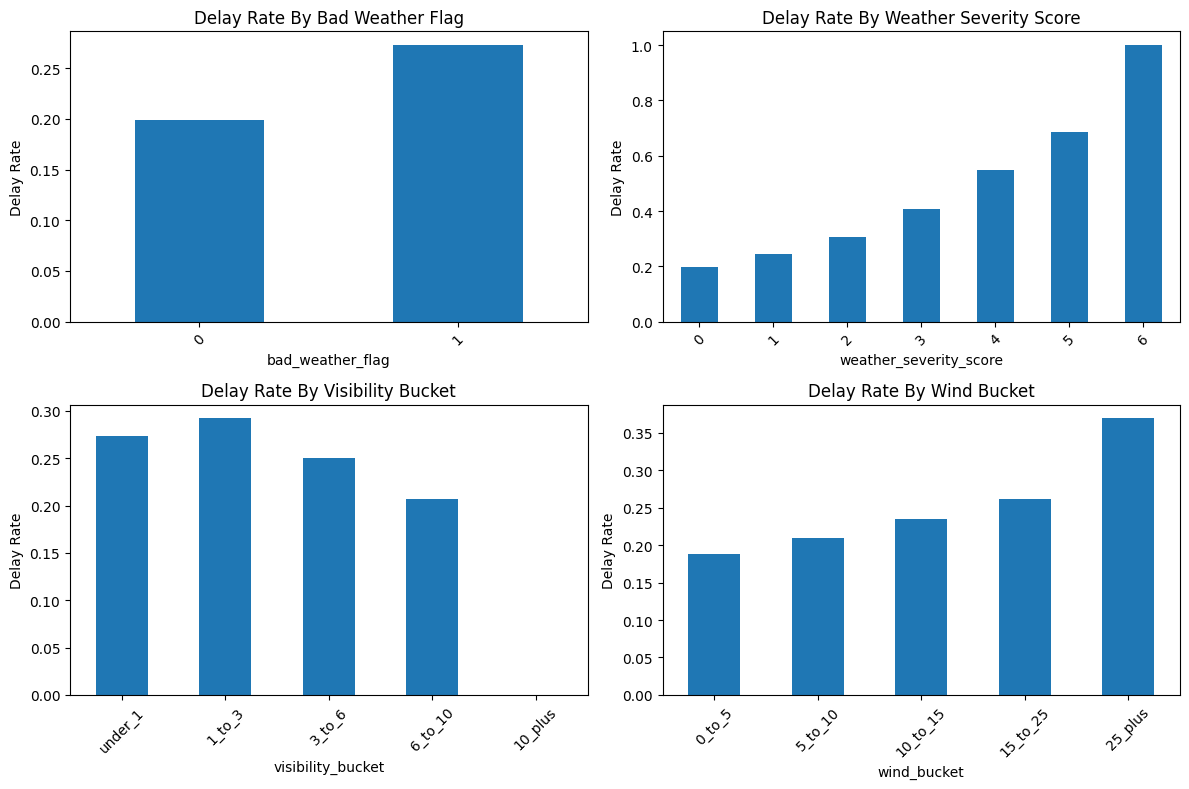

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

df.groupby("bad_weather_flag")["Delay"].mean().plot(kind="bar", ax=axes[0, 0], title="Delay Rate By Bad Weather Flag")
df.groupby("weather_severity_score")["Delay"].mean().plot(kind="bar", ax=axes[0, 1], title="Delay Rate By Weather Severity Score")
df.groupby("visibility_bucket", observed=False)["Delay"].mean().plot(kind="bar", ax=axes[1, 0], title="Delay Rate By Visibility Bucket")
df.groupby("wind_bucket", observed=False)["Delay"].mean().plot(kind="bar", ax=axes[1, 1], title="Delay Rate By Wind Bucket")

for ax in axes.ravel():
    ax.set_ylabel("Delay Rate")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()


## Sample Model Comparison


In [5]:
train_df = df[df["FlightDate"].dt.year == 2022].copy()
test_df = df[df["FlightDate"].dt.year == 2023].copy()

base_numeric = ["DayOfWeek", "dep_hour", "is_weekend"]
base_categorical = ["Reporting_Airline", "Origin", "Dest", "route", "time_of_day_bin"]

raw_weather_numeric = ["tmpf", "relh", "sknt", "alti", "vsby", "p01i", "weather_report_age_minutes"]
engineered_weather_numeric = [
    "has_precip",
    "low_visibility",
    "very_low_visibility",
    "high_wind",
    "very_high_wind",
    "freezing_temp",
    "hot_temp",
    "low_pressure",
    "bad_weather_flag",
    "weather_severity_score",
    "precip_and_wind",
    "precip_and_low_visibility",
]
engineered_weather_categorical = ["visibility_bucket", "wind_bucket"]

feature_sets = {
    "Flight Only": {
        "numeric": base_numeric,
        "categorical": base_categorical,
    },
    "Flight + Raw Weather": {
        "numeric": base_numeric + raw_weather_numeric,
        "categorical": base_categorical,
    },
    "Flight + Engineered Weather": {
        "numeric": base_numeric + raw_weather_numeric + engineered_weather_numeric,
        "categorical": base_categorical + engineered_weather_categorical,
    },
}


def build_sample_pipeline(numeric_features, categorical_features):
    preprocessor = ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), categorical_features),
    ])

    return Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=75,
            max_depth=12,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        )),
    ])


results = []
models = {}

for name, spec in feature_sets.items():
    features = spec["numeric"] + spec["categorical"]
    model = build_sample_pipeline(spec["numeric"], spec["categorical"])
    model.fit(train_df[features], train_df["Delay"])
    y_pred = model.predict(test_df[features])

    results.append({
        "feature_set": name,
        "accuracy": accuracy_score(test_df["Delay"], y_pred),
        "precision_delay": precision_score(test_df["Delay"], y_pred, pos_label=1, zero_division=0),
        "recall_delay": recall_score(test_df["Delay"], y_pred, pos_label=1, zero_division=0),
        "f1_delay": f1_score(test_df["Delay"], y_pred, pos_label=1, zero_division=0),
    })
    models[name] = model

weather_results = pd.DataFrame(results).sort_values("f1_delay", ascending=False)
weather_results


,feature_set,accuracy,precision_delay,recall_delay,f1_delay
2,Flight + Engineered Weather,0.640647,0.313512,0.589012,0.409213
1,Flight + Raw Weather,0.594851,0.293654,0.652833,0.405092
0,Flight Only,0.602557,0.293072,0.623883,0.398804


## Feature Importance


In [6]:
best_name = weather_results.iloc[0]["feature_set"]
best_model = models[best_name]

feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
importances = best_model.named_steps["classifier"].feature_importances_

importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

importance_df.head(20)


,feature,importance
0,cat__time_of_day_bin_morning,0.110953
1,num__dep_hour,0.105160
2,cat__time_of_day_bin_evening,0.070126
3,cat__Reporting_Airline_WN,0.043890
4,num__tmpf,0.038116
5,num__weather_severity_score,0.035965
6,num__bad_weather_flag,0.030603
7,num__alti,0.026530
8,num__DayOfWeek,0.025044
9,num__p01i,0.023313


## Takeaway

Engineered weather features help a little on this sample, but they do not change the main project story.
